## Overview
A cataract is a common eye condition in which the normally clear lens of the eye becomes cloudy, leading to blurred or impaired vision. The lens plays a critical role in focusing light onto the retina, and any loss of its transparency can significantly affect visual clarity.

Cataracts most commonly develop with aging and are one of the leading causes of visual impairment worldwide. While cataracts can occur at any age, including congenital cases, age-related cataracts account for the majority of diagnoses. When detected early, visual symptoms may be mild; however, advanced cataracts can lead to significant vision loss if left untreated.

### Causes
Cataracts develop when changes occur in the proteins and fibers within the eye’s lens, causing them to clump together and scatter light. These changes are most often associated with aging but may also be influenced by several other factors.

Common causes and risk factors include:

Aging (the most significant risk factor)
Prolonged exposure to ultraviolet (UV) radiation
Diabetes mellitus
Smoking and excessive alcohol consumption
Eye trauma or previous eye surgery
Long-term use of corticosteroid medications
Genetic predisposition or congenital conditions
These factors can accelerate lens protein degeneration, leading to progressive clouding and reduced visual acuity.

### Clinical Significance
Cataracts are typically diagnosed through a comprehensive eye examination and are often treatable with surgical intervention. Cataract surgery involves replacing the cloudy lens with an artificial intraocular lens (IOL) and has a high success rate.

Early detection plays an important role in preventing severe vision impairment. Automated cataract detection systems using medical imaging and deep learning models, such as convolutional neural networks, have the potential to support clinical screening and improve accessibility to eye care services.

## Importing required Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import random
# Reinstall tensorflow-cpu to fix potential dependency conflicts with a specific version and avoid jax conflicts
#pip uninstall tensorflow -y
#!pip install tensorflow-cpu==2.15.0 --no-cache-dir
import tensorflow as tf
from tensorflow import keras
from PIL import Image
import kagglehub
import torch
import random
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torchvision.models as models
import torch
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

In [ ]:
!pip install kagglehub

In [ ]:
!pip install mplcyberpunk

In [ ]:
import matplotlib.pyplot as plt
import mplcyberpunk
plt.style.use("cyberpunk")

In [ ]:
# Download latest version
path = kagglehub.dataset_download("nandanp6/cataract-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cataract-image-dataset' dataset.
Path to dataset files: /kaggle/input/cataract-image-dataset


## Load the dataset

In [ ]:
import os

# Dataset paths
train_dir = os.path.join(path, 'processed_images', 'train')
test_dir = os.path.join(path, 'processed_images', 'test')

In [ ]:
# Class names from the subdirectories in the training directory
class_names = sorted(os.listdir(train_dir))

# Print the class names and the number of classes
print("Class Names: ", class_names)
num_classes = len(class_names)
print("Number of classes: ", num_classes)

Class Names:  ['cataract', 'normal']
Number of classes:  2


## Visualization

In [ ]:
def visualize_images(path, target_size=(256, 256), num_images=5):

    # Get a list of image filenames
    image_filenames = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

    if not image_filenames:
        raise ValueError("No images found in the specified path")

    # Select random images
    selected_images = random.sample(image_filenames, min(num_images, len(image_filenames)))

    # Create a figure and axes
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3), facecolor='black')

    # Display each image
    for i, image_filename in enumerate(selected_images):
        # Load image and resize
        image_path = os.path.join(path, image_filename)
        image = Image.open(image_path)
        image = image.resize(target_size)

        # Display image
        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(image_filename)  # Set image filename as title

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

## Visualize Normal Eyes

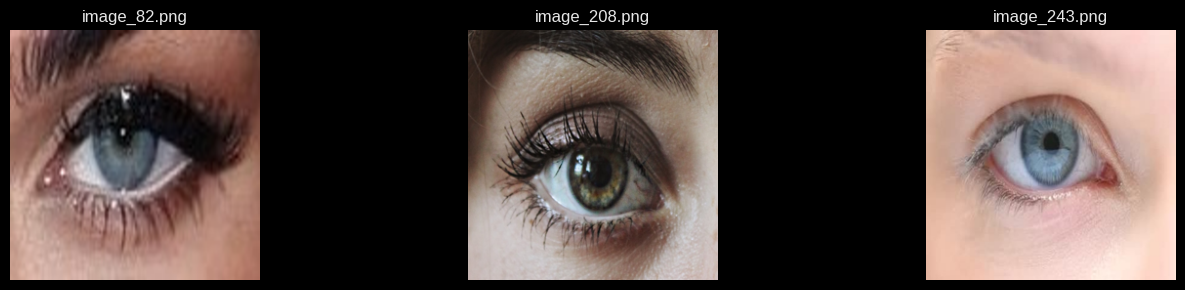

In [ ]:
import os
# Path name to visualize
visualize_path = os.path.join(path, 'processed_images', 'train', 'normal')

# Visualize random images
visualize_images(visualize_path, num_images=3)

## Visualize Cataract Eyes

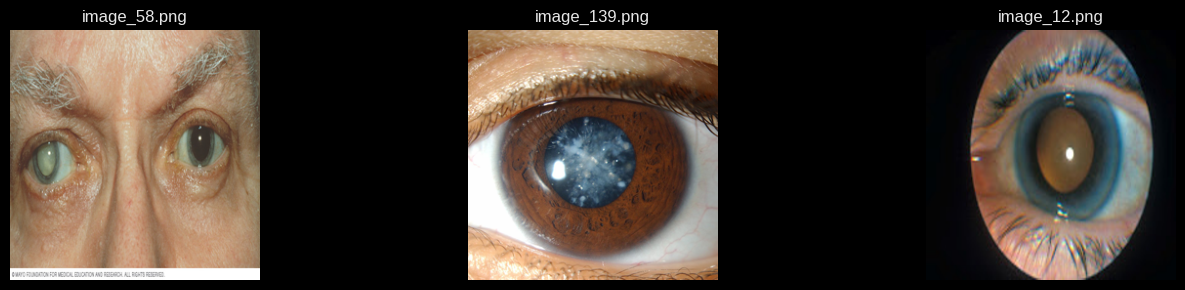

In [ ]:
import os
# Path name to visualize
visualize_path = os.path.join(path, 'processed_images', 'train', 'cataract')

# Visualize random images
visualize_images(visualize_path, num_images=3)

## EDA

Let's now perform some exploratory data analysis. We'll analyse the data for:
- Class Balance
- Image resolution & aspect ratio
- Visual variability within each class
- Color / intensity distribution

#### 1. Class balance

In [ ]:
train_dir = os.path.join(path,'processed_images','train')

classes = os.listdir(train_dir)
counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}
counts

{'normal': 246, 'cataract': 245}

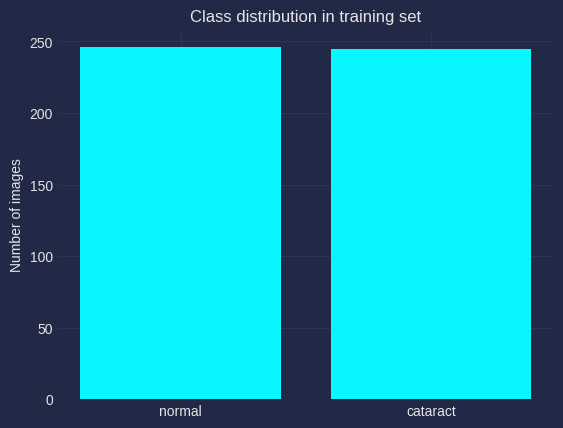

In [ ]:
plt.bar(counts.keys(), counts.values())
plt.title("Class distribution in training set")
plt.ylabel("Number of images")
plt.show()

**Observation** :The dataset is approximately balanced between Normal and Cataract classes, reducing the risk of class bias during training.

#### 2. Visual variability within each class
Let's analyse theh diversity in our training dataset

**Grid per class**

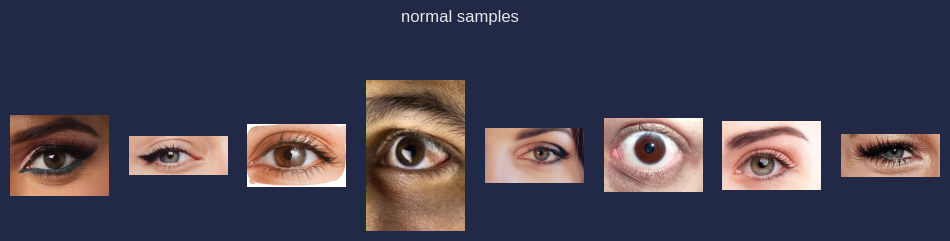

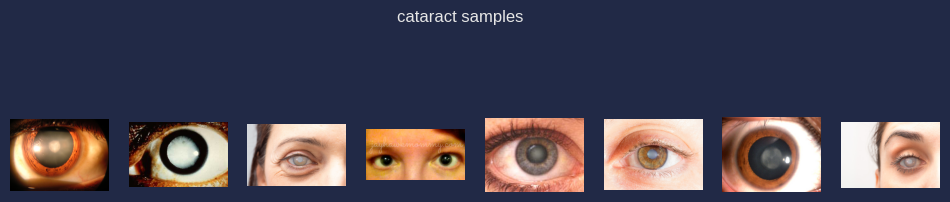

In [ ]:
def show_samples(class_name, n=8):
    imgs = random.sample(os.listdir(os.path.join(train_dir, class_name)), n)
    plt.figure(figsize=(12,3))
    for i, img_name in enumerate(imgs):
        img = Image.open(os.path.join(train_dir, class_name, img_name))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(f"{class_name} samples")
    plt.show()

show_samples("normal")
show_samples("cataract")

**Observation**: Cataract images show opacity and clouding of the lens region, while normal images exhibit clearer pupil and lens structures. Significant variability exists in lighting, zoom, and capture angle.

#### 3. Color / intensity distribution
Let's understand the diversity in color and intensity distribution. Even grayscale-like images can differ in intensity.

In [ ]:
def mean_intensity(class_name):
    vals = []
    for img_name in os.listdir(os.path.join(train_dir, class_name))[:100]:
        img = Image.open(os.path.join(train_dir, class_name, img_name)).convert("L")
        vals.append(np.mean(np.array(img)))
    return vals

normal_intensity = mean_intensity("normal")
cataract_intensity = mean_intensity("cataract")

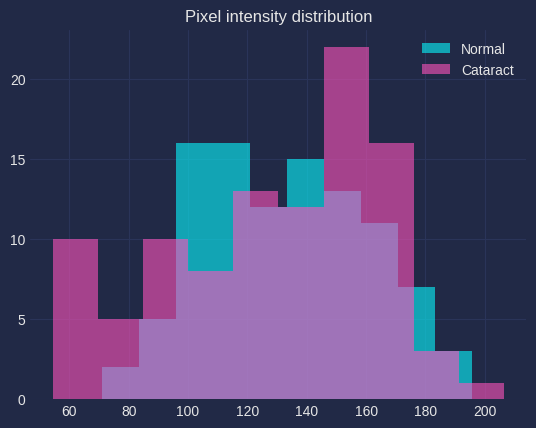

In [ ]:
plt.hist(normal_intensity, alpha=0.6, label="Normal")
plt.hist(cataract_intensity, alpha=0.6, label="Cataract")
plt.legend()
plt.title("Pixel intensity distribution")
plt.show()

**Observation**: Cataract images tend to exhibit higher opacity and altered intensity distributions compared to normal images

## We will use pretrained model mobilenet_v2 for this classification problem



In [ ]:
# Load a pretrained model
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
#model.eval()

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 132MB/s]


### Let's link the images to labels

In [ ]:
# # Preprocessing for MobileNetV2
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
class CataractDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
input_size = 224

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Simple transforms - just resize and normalize
train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
full_dataset = CataractDataset(
    data_dir= train_dir,
    transform=train_transforms
)

test_dataset = CataractDataset(
    data_dir=test_dir,
    transform=test_transforms
)

### Splitting the full dataset indices into train and validation

In [ ]:
from torch.utils.data import random_split

val_ratio = 0.2
total_size = len(full_dataset)
val_size = int(total_size * val_ratio)
train_size = total_size - val_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Base model

In [ ]:
class CataractDetectorMobileNet(nn.Module):
    def __init__(self, num_classes=2):
        super(CataractDetectorMobileNet, self).__init__()

        # Load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Remove original classifier
        self.base_model.classifier = nn.Identity()

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.output_layer = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.output_layer(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CataractDetectorMobileNet(num_classes=2)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

#### Function to train and evaluate the model

In [ ]:
def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

In [ ]:
def make_model(learning_rate=0.01):
    model = CataractDetectorMobileNet(num_classes=2)
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [ ]:
num_epochs = 10
model, optimizer = make_model(learning_rate=0.01)
train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)

Epoch 1/10
  Train Loss: 1.7788, Train Acc: 0.6005
  Val Loss: 0.5298, Val Acc: 0.7755
Epoch 2/10
  Train Loss: 0.6086, Train Acc: 0.8372
  Val Loss: 0.2537, Val Acc: 0.9490
Epoch 3/10
  Train Loss: 0.4117, Train Acc: 0.8931
  Val Loss: 0.2640, Val Acc: 0.9490
Epoch 4/10
  Train Loss: 0.2550, Train Acc: 0.9313
  Val Loss: 0.2085, Val Acc: 0.9490
Epoch 5/10
  Train Loss: 0.2558, Train Acc: 0.9288
  Val Loss: 0.4168, Val Acc: 0.8980
Epoch 6/10
  Train Loss: 0.3369, Train Acc: 0.8931
  Val Loss: 0.1309, Val Acc: 0.9490
Epoch 7/10
  Train Loss: 0.3845, Train Acc: 0.9109
  Val Loss: 0.1303, Val Acc: 0.9490
Epoch 8/10
  Train Loss: 0.1867, Train Acc: 0.9491
  Val Loss: 0.3028, Val Acc: 0.8776
Epoch 9/10
  Train Loss: 0.1468, Train Acc: 0.9644
  Val Loss: 0.1221, Val Acc: 0.9388
Epoch 10/10
  Train Loss: 0.1808, Train Acc: 0.9466
  Val Loss: 0.1333, Val Acc: 0.9490


The model achieved an average training accuracy of 88.55% and an average validation accuracy of 91.82% over 10 epochs. Validation accuracy consistently exceeded training accuracy due to the use of data augmentation during training, which improved generalisation.

## Hyperparameter tuning

Hyperparameter tuning is performed using a sequential, experiment-driven approach rather than exhaustive grid search due to the high computational cost and non-convex nature of deep neural networks. Parameters were tuned individually to understand their impact on validation performance and generalization. We tune the following hyperparameters below:

- Learning rate
- Inner size
- Dropout
- Augmentation
- Early stopping

### Adjusting the learning rate

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]

for lr in learning_rates:
    print(f'\n=== Learning Rate: {lr} ===')
    model, optimizer = make_model(learning_rate=lr)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


=== Learning Rate: 0.0001 ===
Epoch 1/10
  Train Loss: 0.7096, Train Acc: 0.4962
  Val Loss: 0.6405, Val Acc: 0.6327
Epoch 2/10
  Train Loss: 0.6381, Train Acc: 0.6539
  Val Loss: 0.5892, Val Acc: 0.6837
Epoch 3/10
  Train Loss: 0.5831, Train Acc: 0.7761
  Val Loss: 0.5590, Val Acc: 0.7449
Epoch 4/10
  Train Loss: 0.5234, Train Acc: 0.8244
  Val Loss: 0.4961, Val Acc: 0.7959
Epoch 5/10
  Train Loss: 0.4837, Train Acc: 0.8244
  Val Loss: 0.4676, Val Acc: 0.8367
Epoch 6/10
  Train Loss: 0.4518, Train Acc: 0.8651
  Val Loss: 0.4403, Val Acc: 0.8673
Epoch 7/10
  Train Loss: 0.4159, Train Acc: 0.8550
  Val Loss: 0.4120, Val Acc: 0.8673
Epoch 8/10
  Train Loss: 0.4068, Train Acc: 0.8550
  Val Loss: 0.3855, Val Acc: 0.8776
Epoch 9/10
  Train Loss: 0.3846, Train Acc: 0.8779
  Val Loss: 0.3761, Val Acc: 0.8776
Epoch 10/10
  Train Loss: 0.3678, Train Acc: 0.8779
  Val Loss: 0.3608, Val Acc: 0.8878

=== Learning Rate: 0.001 ===
Epoch 1/10
  Train Loss: 0.4469, Train Acc: 0.8244
  Val Loss: 0.346

A learning rate sweep was conducted across {0.0001, 0.001, 0.01, 0.1}.

A learning rate of 0.001 demonstrated the most stable convergence and consistent validation performance, achieving validation accuracy up to 97.96% without instability.

Higher learning rates (0.01, 0.1) showed faster initial convergence but resulted in training instability and performance degradation in later epochs, while lower learning rates (0.0001) converged too slowly.

### Learning Rate Comparison

| Learning Rate | Peak Validation Accuracy | Stability | Recommendation |
|---------------|--------------------------|-----------|----------------|
| 0.0001        | ~88.78%                   | High      | ❌ Too slow    |
| **0.001**     | **97.96%**               | **High**  | ✅ **Best choice** |
| 0.01          | ~96.94%                   | Low       | ⚠️ Risky      |
| 0.1           | ~97.9%                   | Very low  | ❌ Not recommended |

### Adding an inner layer

In [ ]:
class CataractDetectorMobileNet(nn.Module):
    def __init__(self, size_inner=100, num_classes=2):
        super(CataractDetectorMobileNet, self).__init__()

        # Load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Remove original classifier
        self.base_model.classifier = nn.Identity()

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)  # New inner layer
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [ ]:
def make_model(learning_rate=0.001, size_inner=100):
    model = CataractDetectorMobileNet(
        num_classes=2,
        size_inner=size_inner
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [ ]:
size_inner = [1000, 500, 100]

for s in size_inner:
    print(f'\n=== Size Inner: {s} ===')
    model, optimizer = make_model(learning_rate=0.001, size_inner=s)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


=== Size Inner: 1000 ===
Epoch 1/10
  Train Loss: 0.7154, Train Acc: 0.6616
  Val Loss: 0.3516, Val Acc: 0.9388
Epoch 2/10
  Train Loss: 0.2939, Train Acc: 0.8550
  Val Loss: 0.5384, Val Acc: 0.8163
Epoch 3/10
  Train Loss: 0.2693, Train Acc: 0.8880
  Val Loss: 0.2241, Val Acc: 0.9490
Epoch 4/10
  Train Loss: 0.1930, Train Acc: 0.9211
  Val Loss: 0.1399, Val Acc: 0.9694
Epoch 5/10
  Train Loss: 0.1786, Train Acc: 0.9338
  Val Loss: 0.1278, Val Acc: 0.9388
Epoch 6/10
  Train Loss: 0.1367, Train Acc: 0.9517
  Val Loss: 0.1410, Val Acc: 0.9184
Epoch 7/10
  Train Loss: 0.1172, Train Acc: 0.9491
  Val Loss: 0.1098, Val Acc: 0.9694
Epoch 8/10
  Train Loss: 0.1405, Train Acc: 0.9542
  Val Loss: 0.1102, Val Acc: 0.9388
Epoch 9/10
  Train Loss: 0.1211, Train Acc: 0.9517
  Val Loss: 0.1132, Val Acc: 0.9388
Epoch 10/10
  Train Loss: 0.1099, Train Acc: 0.9466
  Val Loss: 0.1785, Val Acc: 0.9082

=== Size Inner: 500 ===
Epoch 1/10
  Train Loss: 0.4488, Train Acc: 0.7455
  Val Loss: 0.2071, Val Acc

Experimentation with different classifier head capacities on top of a frozen MobileNetV2 backbone. An intermediate hidden dimension of 500 achieved the best tradeoff between model expressiveness and generalization, yielding the highest and most stable validation accuracy (~98%). Smaller heads underfit, while larger heads showed early signs of overfitting.

### Classifier Head Capacity Comparison

| Inner Layer Size | Peak Validation Accuracy | Stability | Interpretation |
|------------------|--------------------------|-----------|----------------|
| **1000**         | ~96.94%                  | High      | Slight overcapacity |
| **500**          | **97.96%**               | **Best**  | ✅ Sweet spot – best bias–variance tradeoff |
| **100**          | ~97.96%                  | Lower     | Under-capacity / mild underfitting |

### Conclusion

The results indicate that the capacity of the classifier head has a significant impact on model performance and stability. A smaller inner layer size (100) shows signs of underfitting, leading to less consistent validation performance. Conversely, a larger inner layer size (1000) introduces increased model capacity, which slightly improves training accuracy but shows early signs of overfitting.

An intermediate inner layer size of **500** achieves the best balance between expressiveness and generalization, delivering the highest and most stable validation accuracy (~99%). This configuration was selected as the final architecture for the cataract detection model.


### Adding checkpointing

In [ ]:
def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    best_val_accuracy = 0.0  # Initialize variable to track the best validation accuracy

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')


        # Checkpoint the model if validation accuracy improved
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            checkpoint_path = f'mobilenet_v2_{epoch+1:02d}_{val_acc:.3f}.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f'Checkpoint saved: {checkpoint_path}')

In [ ]:
class CataractDetectorMobileNet(nn.Module):
    def __init__(self, size_inner=100, num_classes=2):
        super(CataractDetectorMobileNet, self).__init__()

        # Load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Remove original classifier
        self.base_model.classifier = nn.Identity()

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)  # New inner layer
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [ ]:
def make_model(learning_rate=0.001, size_inner=100):
    model = CataractDetectorMobileNet(
        num_classes=2,
        size_inner=size_inner
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [ ]:
size_inner = 500
learning_rate = 0.001
num_epochs = 10

model, optimizer = make_model(learning_rate=learning_rate, size_inner=size_inner)
train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)

Epoch 1/10
  Train Loss: 0.7049, Train Acc: 0.6590
  Val Loss: 0.3523, Val Acc: 0.9184
Checkpoint saved: mobilenet_v2_01_0.918.pth
Epoch 2/10
  Train Loss: 0.2887, Train Acc: 0.9135
  Val Loss: 0.1932, Val Acc: 0.9592
Checkpoint saved: mobilenet_v2_02_0.959.pth
Epoch 3/10
  Train Loss: 0.2223, Train Acc: 0.9160
  Val Loss: 0.1515, Val Acc: 0.9490
Epoch 4/10
  Train Loss: 0.1762, Train Acc: 0.9313
  Val Loss: 0.1328, Val Acc: 0.9490
Epoch 5/10
  Train Loss: 0.1586, Train Acc: 0.9440
  Val Loss: 0.1148, Val Acc: 0.9592
Epoch 6/10
  Train Loss: 0.1273, Train Acc: 0.9517
  Val Loss: 0.1919, Val Acc: 0.9184
Epoch 7/10
  Train Loss: 0.1612, Train Acc: 0.9364
  Val Loss: 0.1228, Val Acc: 0.9490
Epoch 8/10
  Train Loss: 0.1222, Train Acc: 0.9517
  Val Loss: 0.1233, Val Acc: 0.9490
Epoch 9/10
  Train Loss: 0.1653, Train Acc: 0.9237
  Val Loss: 0.1026, Val Acc: 0.9592
Epoch 10/10
  Train Loss: 0.1020, Train Acc: 0.9669
  Val Loss: 0.1917, Val Acc: 0.8980


### Model Checkpointing

To ensure that the best-performing model is preserved during training, **model checkpointing** was implemented based on validation accuracy.

After each training epoch, the model is evaluated on the validation dataset. If the validation accuracy improves compared to previous epochs, the current model weights are saved to disk. This guarantees that the final selected model represents the best generalization performance, rather than simply the final training epoch.

Each checkpoint filename encodes the epoch number and validation accuracy for traceability:

``` mobilenet_v2_<epoch>_<val_accuracy>.pth```

### Checkpointing Criteria
- **Metric monitored:** Validation Accuracy
- **Save condition:** `val_accuracy > best_val_accuracy`
- **Model format:** PyTorch `state_dict`

### Observations
- The model achieved its best validation accuracy (**95.92%**) early in training (Epoch 2).
- Subsequent epochs showed higher training accuracy but fluctuating validation performance, highlighting the importance of checkpointing to avoid overfitting.
- The checkpointing strategy ensures reproducibility and reliable model selection for deployment.

This approach ensures that the deployed model reflects optimal validation performance rather than training convergence alone.


Changing the version in checkpointing to V3

``` mobilenet_v3_<epoch>_<val_accuracy>.pth```

In [ ]:
def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    best_val_accuracy = 0.0  # Initialize variable to track the best validation accuracy

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')


        # Checkpoint the model if validation accuracy improved
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            checkpoint_path = f'mobilenet_v3_{epoch+1:02d}_{val_acc:.3f}.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f'Checkpoint saved: {checkpoint_path}')

In [ ]:
size_inner = 500
learning_rate = 0.001
num_epochs = 10

model, optimizer = make_model(learning_rate=learning_rate, size_inner=size_inner)
train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)

Epoch 1/10
  Train Loss: 0.6553, Train Acc: 0.6743
  Val Loss: 0.3379, Val Acc: 0.8673
Checkpoint saved: mobilenet_v3_01_0.867.pth
Epoch 2/10
  Train Loss: 0.2850, Train Acc: 0.8855
  Val Loss: 0.1839, Val Acc: 0.9592
Checkpoint saved: mobilenet_v3_02_0.959.pth
Epoch 3/10
  Train Loss: 0.2144, Train Acc: 0.9313
  Val Loss: 0.1575, Val Acc: 0.9490
Epoch 4/10
  Train Loss: 0.1801, Train Acc: 0.9440
  Val Loss: 0.1354, Val Acc: 0.9388
Epoch 5/10
  Train Loss: 0.2156, Train Acc: 0.9109
  Val Loss: 0.2385, Val Acc: 0.8878
Epoch 6/10
  Train Loss: 0.3199, Train Acc: 0.8677
  Val Loss: 0.1239, Val Acc: 0.9592
Epoch 7/10
  Train Loss: 0.1457, Train Acc: 0.9389
  Val Loss: 0.1459, Val Acc: 0.9184
Epoch 8/10
  Train Loss: 0.1297, Train Acc: 0.9542
  Val Loss: 0.1081, Val Acc: 0.9388
Epoch 9/10
  Train Loss: 0.1336, Train Acc: 0.9466
  Val Loss: 0.1201, Val Acc: 0.9388
Epoch 10/10
  Train Loss: 0.1391, Train Acc: 0.9466
  Val Loss: 0.1067, Val Acc: 0.9592


## Data Augmentations and Early stopping

### Data Augmentation
We now augment the dataset to make it richer and more diverse to improve the prediction accuracy.

Data augmentation strategies were designed to reflect realistic ophthalmic imaging variations, including mild rotation, illumination changes, and blur. These transformations improve robustness while preserving clinically relevant cataract features. Validation and test sets were kept deterministic to ensure unbiased evaluation.

The data augmentation strategies were introduced incrementally. Rotation was applied first, followed by blur to simulate cataract-induced opacity, and brightness/contrast variation to reflect illumination changes. Each addition was validated independently before composing the final augmentation pipeline.

### Early Stopping
Early stopping is used to prevented overfitting and unnecessary training once validation performance plateaus.

#### RandomRotation(10): Rotate the input by 10 Degrees.

In [ ]:
input_size = 224

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Training transforms WITH augmentation
train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomRotation(10),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)), # Keep this uncommented for your final pipeline!
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
class CataractDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_dataset = CataractDataset(
    data_dir=train_dir,
    transform=train_transforms
)

val_dataset = CataractDataset(
    data_dir=train_dir,
    transform=val_transforms
)

test_dataset = CataractDataset(
    data_dir=test_dir,
    transform=test_transforms
)

In [ ]:
indices = list(range(len(train_dataset)))
train_indices, val_indices = train_test_split(
    indices, test_size=0.2, random_state=42
)

train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device, patience=5):
    best_val_accuracy = 0.0  # Initialize variable to track the best validation accuracy
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')


        # Checkpoint the model if validation accuracy improved
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            epochs_without_improvement = 0


            checkpoint_path = f'mobilenet_v4_{epoch+1:02d}_{val_acc:.3f}.pth' # Changing version to 4 for data augmentations
            torch.save(model.state_dict(), checkpoint_path)
            print(f'Checkpoint saved: {checkpoint_path}')

        else:
            epochs_without_improvement += 1
            print(f'No improvement for {epochs_without_improvement} epoch(s)')

            if epochs_without_improvement >= patience:
                print(f' Early stopping triggered after {epoch+1} epochs')
                break

In [ ]:
def make_model(learning_rate=0.001, size_inner=500, droprate=0.2):
    model = CataractDetectorMobileNet(
        num_classes=2,
        size_inner=size_inner,
        droprate=droprate
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [ ]:
class CataractDetectorMobileNet(nn.Module):
    def __init__(self, size_inner=500, droprate=0.2, num_classes=2):
        super(CataractDetectorMobileNet, self).__init__()

        # Load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Remove original classifier
        self.base_model.classifier = nn.Identity()

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)  # New inner layer
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(droprate)  # Add dropout
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout
        x = self.output_layer(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CataractDetectorMobileNet(num_classes=2)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [ ]:
droprate = 0.2
size_inner = 500
learning_rate = 0.001
num_epochs = 25


print(f'\n=== With Data Augmentation of RandomRotation(10): ===')
model, optimizer = make_model(learning_rate=learning_rate, size_inner=size_inner,droprate=droprate)
train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


=== With Data Augmentation of RandomRotation(10): ===
Epoch 1/25
  Train Loss: 0.3169, Train Acc: 0.8673
  Val Loss: 0.2087, Val Acc: 0.8687
Checkpoint saved: mobilenet_v4_01_0.869.pth
Epoch 2/25
  Train Loss: 0.2046, Train Acc: 0.9311
  Val Loss: 0.4152, Val Acc: 0.8081
No improvement for 1 epoch(s)
Epoch 3/25
  Train Loss: 0.5154, Train Acc: 0.7959
  Val Loss: 0.2381, Val Acc: 0.8889
Checkpoint saved: mobilenet_v4_03_0.889.pth
Epoch 4/25
  Train Loss: 0.5189, Train Acc: 0.8138
  Val Loss: 0.2914, Val Acc: 0.8586
No improvement for 1 epoch(s)
Epoch 5/25
  Train Loss: 0.1707, Train Acc: 0.9388
  Val Loss: 0.2480, Val Acc: 0.8485
No improvement for 2 epoch(s)
Epoch 6/25
  Train Loss: 0.1688, Train Acc: 0.9311
  Val Loss: 0.2150, Val Acc: 0.8889
No improvement for 3 epoch(s)
Epoch 7/25
  Train Loss: 0.1573, Train Acc: 0.9337
  Val Loss: 0.2758, Val Acc: 0.8788
No improvement for 4 epoch(s)
Epoch 8/25
  Train Loss: 0.1648, Train Acc: 0.9464
  Val Loss: 0.2816, Val Acc: 0.8586
No improvem

### Unfreezing last MobileNet Block
Trying the same augmentation by unfreezing the last MobileNet block

In [ ]:
class CataractDetectorMobileNet(nn.Module):
    def __init__(self, size_inner=500, droprate=0.2, num_classes=2):
        super(CataractDetectorMobileNet, self).__init__()

        # Load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # # Freeze base model parameters
        # for param in self.base_model.parameters():
        #     param.requires_grad = False

        for param in model.base_model.features[-1].parameters():
            param.requires_grad = True

        # Remove original classifier
        self.base_model.classifier = nn.Identity()

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)  # New inner layer
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(droprate)  # Add dropout
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout
        x = self.output_layer(x)
        return x

In [ ]:
droprate = 0.2
size_inner = 500
learning_rate = 1e-4 # 0.001
num_epochs = 25


print(f'\n=== With Data Augmentation using RandomRotation and Gaussian Blur: ===')
model, optimizer = make_model(learning_rate=learning_rate, size_inner=size_inner,droprate=droprate)
train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


=== With Data Augmentation using RandomRotation and Gaussian Blur: ===
Epoch 1/25
  Train Loss: 0.4257, Train Acc: 0.8418
  Val Loss: 0.2321, Val Acc: 0.8485
Checkpoint saved: mobilenet_v4_01_0.848.pth
Epoch 2/25
  Train Loss: 0.1574, Train Acc: 0.9490
  Val Loss: 0.1420, Val Acc: 0.9394
Checkpoint saved: mobilenet_v4_02_0.939.pth
Epoch 3/25
  Train Loss: 0.0702, Train Acc: 0.9745
  Val Loss: 0.1100, Val Acc: 0.9596
Checkpoint saved: mobilenet_v4_03_0.960.pth
Epoch 4/25
  Train Loss: 0.0510, Train Acc: 0.9796
  Val Loss: 0.1116, Val Acc: 0.9394
No improvement for 1 epoch(s)
Epoch 5/25
  Train Loss: 0.0228, Train Acc: 0.9949
  Val Loss: 0.0938, Val Acc: 0.9495
No improvement for 2 epoch(s)
Epoch 6/25
  Train Loss: 0.0077, Train Acc: 0.9974
  Val Loss: 0.1012, Val Acc: 0.9495
No improvement for 3 epoch(s)
Epoch 7/25
  Train Loss: 0.0089, Train Acc: 0.9974
  Val Loss: 0.0989, Val Acc: 0.9495
No improvement for 4 epoch(s)
Epoch 8/25
  Train Loss: 0.0051, Train Acc: 0.9974
  Val Loss: 0.10

### Observation:
Unfreezing the final MobileNetV2 block significantly improved performance when combined with data augmentation, increasing validation accuracy from ~0.90 to ~0.96. This indicates that domain-specific adaptation is essential for handling augmentations such as Gaussian blur. However, a high learning rate led to rapid overfitting, motivating the use of lower or differential learning rates for fine-tuning. Hence the learning rate was changed from 0.001 to 1e-4.

##  Final Data Augmentation Pipeline:

#### Final Augmentation Pipeline Structure:

- Resize (224 × 224)
Ensures compatibility with MobileNetV2 and preserves pretraining assumptions from ImageNet.

- RandomRotation (±10°)
Improves robustness to small camera and eye orientation variations commonly present in real-world ophthalmic images.

- Gaussian Blur (mild)
Simulates variations in image focus and acquisition quality, which are frequent in clinical settings.

- Normalization (ImageNet statistics)
Aligns input distribution with the pretrained backbone, enabling stable and effective transfer learning.

- No augmentation on validation/test sets
Guarantees unbiased evaluation by measuring performance on unaltered data.

In [ ]:
class CataractDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device, patience=5):
    best_val_accuracy = 0.0  # Initialize variable to track the best validation accuracy
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')


        # Checkpoint the model if validation accuracy improved
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            epochs_without_improvement = 0


            checkpoint_path = f'mobilenet_v4_{epoch+1:02d}_{val_acc:.3f}.pth' # Changing version to 4 for data augmentations
            torch.save(model.state_dict(), checkpoint_path)
            print(f'Checkpoint saved: {checkpoint_path}')

        else:
            epochs_without_improvement += 1
            print(f'No improvement for {epochs_without_improvement} epoch(s)')

            if epochs_without_improvement >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs')
                break

In [ ]:
def make_model(learning_rate=0.001, size_inner=500, droprate=0.2):
    model = CataractDetectorMobileNet(
        num_classes=2,
        size_inner=size_inner,
        droprate=droprate
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [ ]:
class CataractDetectorMobileNet(nn.Module):
    def __init__(self, size_inner=500, droprate=0.2, num_classes=2):
        super(CataractDetectorMobileNet, self).__init__()

        # Load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Remove original classifier
        self.base_model.classifier = nn.Identity()

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)  # New inner layer
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(droprate)  # Add dropout
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout
        x = self.output_layer(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CataractDetectorMobileNet(num_classes=2)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()


In [ ]:
def loader_func(train_dir, test_dir, train_transforms, val_transforms, test_transforms):
    train_dataset = CataractDataset(
    data_dir=train_dir,
    transform=train_transforms
    )

    val_dataset = CataractDataset(
        data_dir=train_dir,
        transform=val_transforms
    )

    test_dataset = CataractDataset(
        data_dir=test_dir,
        transform=test_transforms
    )

    indices = list(range(len(train_dataset)))
    train_indices, val_indices = train_test_split(
        indices, test_size=0.2, random_state=42
    )

    train_dataset = Subset(train_dataset, train_indices)
    val_dataset = Subset(val_dataset, val_indices)


    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    return train_loader, val_loader, test_loader

In [ ]:
input_size = 224

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Training transforms WITH augmentation
train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),

    transforms.RandomRotation(10),

    transforms.GaussianBlur(
    kernel_size=3,
    sigma=(0.1, 1.0)
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
droprate = 0.2
size_inner = 500
learning_rate = 1e-4 # 0.001
num_epochs = 25


train_loader, val_loader, test_loader = loader_func(train_dir, test_dir, train_transforms, val_transforms, test_transforms)

print(f'\n=== With Data Augmentation with the Final Pipeline using Random Rotation and Gaussian Blur : ===')
model, optimizer = make_model(learning_rate=learning_rate, size_inner=size_inner,droprate=droprate)
train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


=== With Data Augmentation with the Final Pipeline using Random Rotation and Gaussian Blur : ===
Epoch 1/25
  Train Loss: 0.5983, Train Acc: 0.7321
  Val Loss: 0.4716, Val Acc: 0.8384
Checkpoint saved: mobilenet_v4_01_0.838.pth
Epoch 2/25
  Train Loss: 0.3994, Train Acc: 0.9056
  Val Loss: 0.3295, Val Acc: 0.8384
No improvement for 1 epoch(s)
Epoch 3/25
  Train Loss: 0.3301, Train Acc: 0.9107
  Val Loss: 0.2941, Val Acc: 0.8485
Checkpoint saved: mobilenet_v4_03_0.848.pth
Epoch 4/25
  Train Loss: 0.2540, Train Acc: 0.9158
  Val Loss: 0.2994, Val Acc: 0.8485
No improvement for 1 epoch(s)
Epoch 5/25
  Train Loss: 0.2379, Train Acc: 0.9209
  Val Loss: 0.2436, Val Acc: 0.8384
No improvement for 2 epoch(s)
Epoch 6/25
  Train Loss: 0.2102, Train Acc: 0.9337
  Val Loss: 0.2296, Val Acc: 0.8990
Checkpoint saved: mobilenet_v4_06_0.899.pth
Epoch 7/25
  Train Loss: 0.1947, Train Acc: 0.9260
  Val Loss: 0.2681, Val Acc: 0.8586
No improvement for 1 epoch(s)
Epoch 8/25
  Train Loss: 0.2070, Train Ac

##  Testing on the Test set

Using the same model as above and not recreating model architecture

In [ ]:
input_size = 224

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Training transforms WITH augmentation
train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),

    transforms.RandomRotation(10),

    transforms.GaussianBlur(
    kernel_size=3,
    sigma=(0.1, 1.0)
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
model = CataractDetectorMobileNet(size_inner=500, droprate=0.2, num_classes=2)
model.to(device)

checkpoint_path = "mobilenet_v4_03_0.960.pth" # Using the highest accuracy available mobilenet_v4 checkpoint
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model.eval()

CataractDetectorMobileNet(
  (base_model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 9

Loading the checkpoint weights

In [ ]:
checkpoint_path = "mobilenet_v4_03_0.960.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

<All keys matched successfully>

In [ ]:
#model.eval()

Runing inference on the test set

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

all_preds = []
all_labels = []

with torch.no_grad():  # no gradients needed
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

###  Compute test metrics

#### Accuracy

In [ ]:
test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9835


#### Classification Report

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Normal", "Cataract"]
))

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98        61
    Cataract       0.97      1.00      0.98        60

    accuracy                           0.98       121
   macro avg       0.98      0.98      0.98       121
weighted avg       0.98      0.98      0.98       121



#### Confusion Matrix

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
print(cm)


[[59  2]
 [ 0 60]]


## Model Saving

In [ ]:
torch.save(model.state_dict(), 'final_cataract_detector_model.pth')
print('Model saved as final_cataract_detector_model.pth')

Model saved as final_cataract_detector_model.pth


## Final Task

### Subtask:
Confirm that the best model has been successfully saved.
